In [1]:
def bayes_posterior(sensitivity, specificity, prevalence):
    """
    Calculate P(Disease | Positive test) using Bayes' theorem.
    
    sensitivity: P(positive | disease)
    specificity: P(negative | no disease)
    prevalence:  P(disease) -- the prior
    """
    p_positive_given_disease = sensitivity
    p_positive_given_no_disease = 1 - specificity  # false positive rate
    p_disease = prevalence
    p_no_disease = 1 - prevalence
    
    # Law of total probability: P(positive) across both cases
    p_positive = (p_positive_given_disease * p_disease) + \
                 (p_positive_given_no_disease * p_no_disease)
    
    # Bayes' theorem
    posterior = (p_positive_given_disease * p_disease) / p_positive
    
    return posterior

# Our example from Session 2
result = bayes_posterior(sensitivity=0.99, specificity=0.95, prevalence=0.01)
print(f"P(Disease | Positive) = {result:.4f} ({result*100:.1f}%)")

P(Disease | Positive) = 0.1667 (16.7%)


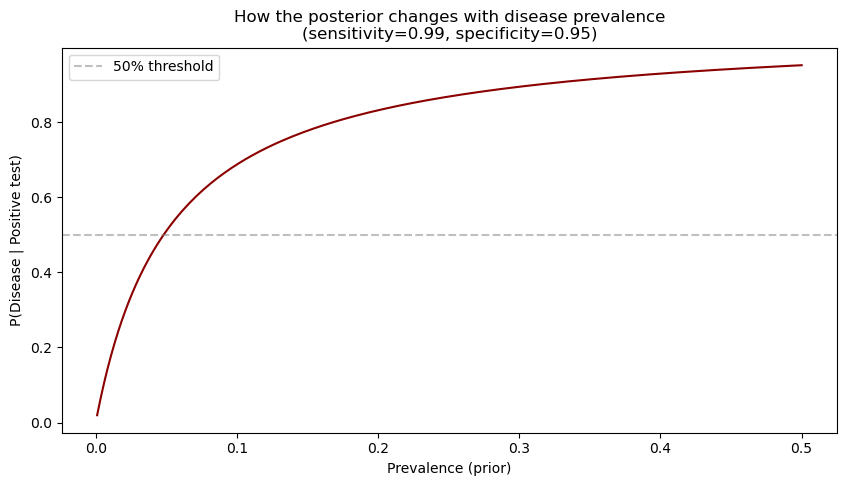

In [2]:
import numpy as np
import matplotlib.pyplot as plt

prevalences = np.linspace(0.001, 0.5, 200)
posteriors = [bayes_posterior(0.99, 0.95, p) for p in prevalences]

plt.figure(figsize=(10, 5))
plt.plot(prevalences, posteriors, color='darkred')
plt.xlabel('Prevalence (prior)')
plt.ylabel('P(Disease | Positive test)')
plt.title("How the posterior changes with disease prevalence\n(sensitivity=0.99, specificity=0.95)")
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
plt.legend()
plt.show()

In [3]:
def explore_bayes(sensitivity, specificity, prevalence):
    posterior = bayes_posterior(sensitivity, specificity, prevalence)
    print(f"Sensitivity: {sensitivity*100:.1f}%")
    print(f"Specificity: {specificity*100:.1f}%")
    print(f"Prevalence:  {prevalence*100:.2f}%")
    print(f"→ P(Disease | Positive test) = {posterior*100:.2f}%")
    print()

# Try a few realistic clinical scenarios
explore_bayes(0.99, 0.95, 0.01)   # rare disease
explore_bayes(0.99, 0.95, 0.10)   # more common disease
explore_bayes(0.99, 0.95, 0.50)   # coin-flip prevalence
explore_bayes(0.99, 0.99, 0.01)   # improved specificity, same rare disease

Sensitivity: 99.0%
Specificity: 95.0%
Prevalence:  1.00%
→ P(Disease | Positive test) = 16.67%

Sensitivity: 99.0%
Specificity: 95.0%
Prevalence:  10.00%
→ P(Disease | Positive test) = 68.75%

Sensitivity: 99.0%
Specificity: 95.0%
Prevalence:  50.00%
→ P(Disease | Positive test) = 95.19%

Sensitivity: 99.0%
Specificity: 99.0%
Prevalence:  1.00%
→ P(Disease | Positive test) = 50.00%



In [5]:
# Toy dataset: word "free" present (1) or absent (0), label spam (1) or not (0)
# In reality you'd have thousands of emails/words - this is a minimal illustration

emails = [
    {"free": 1, "spam": 1},
    {"free": 1, "spam": 1},
    {"free": 0, "spam": 1},
    {"free": 1, "spam": 0},
    {"free": 0, "spam": 0},
    {"free": 0, "spam": 0},
    {"free": 0, "spam": 0},
]

n = len(emails)
n_spam = sum(e["spam"] for e in emails)
n_not_spam = n - n_spam

# Priors
p_spam = n_spam / n
p_not_spam = n_not_spam / n

# Likelihoods: P(free=1 | spam) and P(free=1 | not spam)
p_free_given_spam = sum(e["free"] for e in emails if e["spam"] == 1) / n_spam
p_free_given_not_spam = sum(e["free"] for e in emails if e["spam"] == 0) / n_not_spam

# Bayes: P(spam | free=1)
p_free = (p_free_given_spam * p_spam) + (p_free_given_not_spam * p_not_spam)
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print(f"P(spam) prior = {p_spam:.3f}")
print(f"P('free' | spam) = {p_free_given_spam:.3f}")
print(f"P('free' | not spam) = {p_free_given_not_spam:.3f}")
print(f"P(spam | 'free' present) = {p_spam_given_free:.3f}")

P(spam) prior = 0.429
P('free' | spam) = 0.667
P('free' | not spam) = 0.250
P(spam | 'free' present) = 0.667
